# <div align="center">Cinema Discovery Engine</div>
## <div align="center">CSE488: Big Data Analytics -- Final Assignment</div>
### <div align="center">Md. Sadik Shahriar | 2023-2-60-103</div>

---

**Objective:** Build a hybrid movie recommendation system that addresses the core challenges of real-world recommender systems: **Data Abundance**, **Matrix Sparsity**, and the **Cold Start Problem**. This engine combines Content-Based and Collaborative Filtering strategies to deliver personalized movie recommendations and surface "Hidden Gems" from the Long Tail of the content catalog.

## Table of Contents

1. Environment Setup and Dependencies
2. Data Loading and Exploration
3. Utility Matrix Construction
4. Item-Item Collaborative Filtering
5. Content-Based Filtering (Cold Start Solution)
6. Hybrid Recommendation Strategy
7. Model Evaluation (RMSE)
8. Visualizations and Analysis
9. Streamlit Dashboard Prototype

---
## 1. Environment Setup and Dependencies

This section loads all required Python libraries. The system is built using standard data science tooling:

- **Pandas / NumPy** for data manipulation and numerical operations.
- **SciPy** for sparse matrix construction (handling the utility matrix efficiently).
- **Scikit-learn** for TF-IDF vectorization, cosine similarity, and evaluation metrics.
- **Matplotlib / Seaborn** for data visualization.

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
import time

from scipy.sparse import coo_matrix, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Configure plot aesthetics
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print("All dependencies loaded successfully.")

ModuleNotFoundError: No module named 'pandas'

---
## 2. Data Loading and Exploration

The dataset is based on the **MovieLens 1M** benchmark, containing approximately 1 million ratings from 6,040 users across 3,706 movies. Three CSV files are used:

- **movies.csv**: Movie metadata including title, genre codes, and poster URLs.
- **ratings.csv**: The core user-movie interaction data (ratings from 1.0 to 5.0).
- **users.csv**: User demographic information (gender, age bucket, occupation).

In [ ]:
import pandas as pd

# Load the datasets using absolute Colab paths
ratings_df = pd.read_csv('/content/ratings.csv')
movies_df = pd.read_csv('/content/movies.csv')
users_df = pd.read_csv('/content/users.csv')

print("\nDatasets loaded successfully:")
print("  Movies:  {:,} rows, {} columns".format(movies_df.shape[0], movies_df.shape[1]))
print("  Ratings: {:,} rows, {} columns".format(ratings_df.shape[0], ratings_df.shape[1]))
print("  Users:   {:,} rows, {} columns".format(users_df.shape[0], users_df.shape[1]))


Datasets loaded successfully:
  Movies:  3,706 rows, 4 columns
  Ratings: 1,000,209 rows, 4 columns
  Users:   6,040 rows, 6 columns


In [ ]:
# Define the genre label mapping.
# The movie_genres column uses integer codes corresponding to the following labels.
# This mapping is consistent with the TensorFlow Datasets MovieLens encoding.

GENRE_MAP = {
    0: 'Action',
    1: 'Adventure',
    2: 'Animation',
    3: "Children",
    4: 'Comedy',
    5: 'Crime',
    6: 'Documentary',
    7: 'Drama',
    8: 'Fantasy',
    9: 'Film-Noir',
    10: 'Horror',
    11: 'IMAX',
    12: 'Musical',
    13: 'Mystery',
    14: 'Romance',
    15: 'Sci-Fi',
    16: 'Thriller',
    17: 'War',
    18: 'Western'
}

def map_genre_codes_to_names(genre_codes_str):
    """Convert a comma-separated string of genre codes to readable genre names."""
    codes = str(genre_codes_str).split(',')
    genre_names = []
    for code in codes:
        code = code.strip()
        if code.isdigit():
            genre_names.append(GENRE_MAP.get(int(code), 'Other'))
    return ' | '.join(genre_names) if genre_names else 'Unknown'

# Apply the mapping
movies_df['genres_readable'] = movies_df['movie_genres'].apply(map_genre_codes_to_names)

print("Genre mapping applied. Sample:")
print(movies_df[['movie_title', 'movie_genres', 'genres_readable']].head(10).to_string(index=False))

Genre mapping applied. Sample:
                 movie_title movie_genres                      genres_readable
            Backdraft (1991)         0, 7                       Action | Drama
       Outsiders, The (1983)            7                                Drama
               Junior (1994)        4, 15                      Comedy | Sci-Fi
             Jaws 3-D (1983)        0, 10                      Action | Horror
Spy Who Loved Me, The (1977)            0                               Action
 D2: The Mighty Ducks (1994)         3, 4                    Children | Comedy
          Player, The (1992)         4, 7                       Comedy | Drama
            Key Largo (1948)  5, 7, 9, 16 Crime | Drama | Film-Noir | Thriller
             Phantasm (1979)       10, 15                      Horror | Sci-Fi
  Clockwork Orange, A (1971)           15                               Sci-Fi


### 2.1 Dataset Overview

In [ ]:
print("=" * 80)
print("MOVIES DATASET")
print("=" * 80)
display(movies_df.head())
print("Shape: {}".format(movies_df.shape))
print("Null values per column:")
print(movies_df.isnull().sum())

print()
print("=" * 80)
print("RATINGS DATASET")
print("=" * 80)
display(ratings_df.head())
print("Shape: {}".format(ratings_df.shape))
print("Null values per column:")
print(ratings_df.isnull().sum())
print()
print("Rating statistics:")
display(ratings_df['user_rating'].describe())

print()
print("=" * 80)
print("USERS DATASET")
print("=" * 80)
display(users_df.head())
print("Shape: {}".format(users_df.shape))
print("Null values per column:")
print(users_df.isnull().sum())

MOVIES DATASET


,movie_id,movie_title,movie_genres,poster_url,genres_readable
0,3107,Backdraft (1991),"0, 7",https://image.tmdb.org/t/p/w500/bymJtYNIdiAiBR...,Action | Drama
1,2114,"Outsiders, The (1983)",7,https://image.tmdb.org/t/p/w500/pl8Tf36TAOb2i5...,Drama
2,256,Junior (1994),"4, 15",https://image.tmdb.org/t/p/w500/4tRF43CbEYHmV8...,Comedy | Sci-Fi
3,1389,Jaws 3-D (1983),"0, 10",https://image.tmdb.org/t/p/w500/kqDXj53F9paqVG...,Action | Horror
4,3635,"Spy Who Loved Me, The (1977)",0,https://image.tmdb.org/t/p/w500/3ZxHKFxMYvAko6...,Action


Shape: (3706, 5)
Null values per column:
movie_id            0
movie_title         0
movie_genres        0
poster_url         58
genres_readable     0
dtype: int64

RATINGS DATASET


,user_id,movie_id,user_rating,timestamp
0,130,3107,5.0,977432193
1,3829,2114,4.0,965932967
2,1265,256,1.0,1012103552
3,2896,1389,5.0,972004605
4,5264,3635,4.0,961180111


Shape: (1000209, 4)
Null values per column:
user_id        0
movie_id       0
user_rating    0
timestamp      0
dtype: int64

Rating statistics:


,user_rating
count,1.000209e+06
mean,3.581564e+00
std,1.117102e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,5.000000e+00



USERS DATASET


,user_id,user_gender,bucketized_user_age,user_occupation_label,user_occupation_text,user_zip_code
0,130,True,35.0,18,technician/engineer,50021
1,3829,False,25.0,0,academic/educator,22307
2,1265,False,18.0,21,writer,49321
3,2896,True,18.0,14,sales/marketing,60073
4,5264,True,18.0,17,college/grad student,15217


Shape: (6040, 6)
Null values per column:
user_id                  0
user_gender              0
bucketized_user_age      0
user_occupation_label    0
user_occupation_text     0
user_zip_code            0
dtype: int64


In [ ]:
# --- Data Cleaning ---
print("--- Data Cleaning ---")

dup_count = ratings_df.duplicated(subset=['user_id', 'movie_id']).sum()
print("Duplicate ratings found: {}".format(dup_count))
ratings_df = ratings_df.drop_duplicates(subset=['user_id', 'movie_id'])
print("Ratings after deduplication: {:,}".format(ratings_df.shape[0]))

# Convert timestamp to readable datetime
ratings_df['datetime'] = pd.to_datetime(ratings_df['timestamp'], unit='s')
print("Rating date range: {} to {}".format(
    ratings_df['datetime'].min().strftime('%Y-%m-%d'),
    ratings_df['datetime'].max().strftime('%Y-%m-%d')
))

# Summary
n_users_total = ratings_df['user_id'].nunique()
n_movies_total = ratings_df['movie_id'].nunique()
n_ratings_total = len(ratings_df)
print()
print("Unique Users:  {:,}".format(n_users_total))
print("Unique Movies: {:,}".format(n_movies_total))
print("Total Ratings: {:,}".format(n_ratings_total))
print("Avg Ratings per User:  {:.1f}".format(n_ratings_total / n_users_total))
print("Avg Ratings per Movie: {:.1f}".format(n_ratings_total / n_movies_total))

--- Data Cleaning ---
Duplicate ratings found: 0
Ratings after deduplication: 1,000,209
Rating date range: 2000-04-25 to 2003-02-28

Unique Users:  6,040
Unique Movies: 3,706
Total Ratings: 1,000,209
Avg Ratings per User:  165.6
Avg Ratings per Movie: 269.9


### 2.2 Exploratory Data Analysis

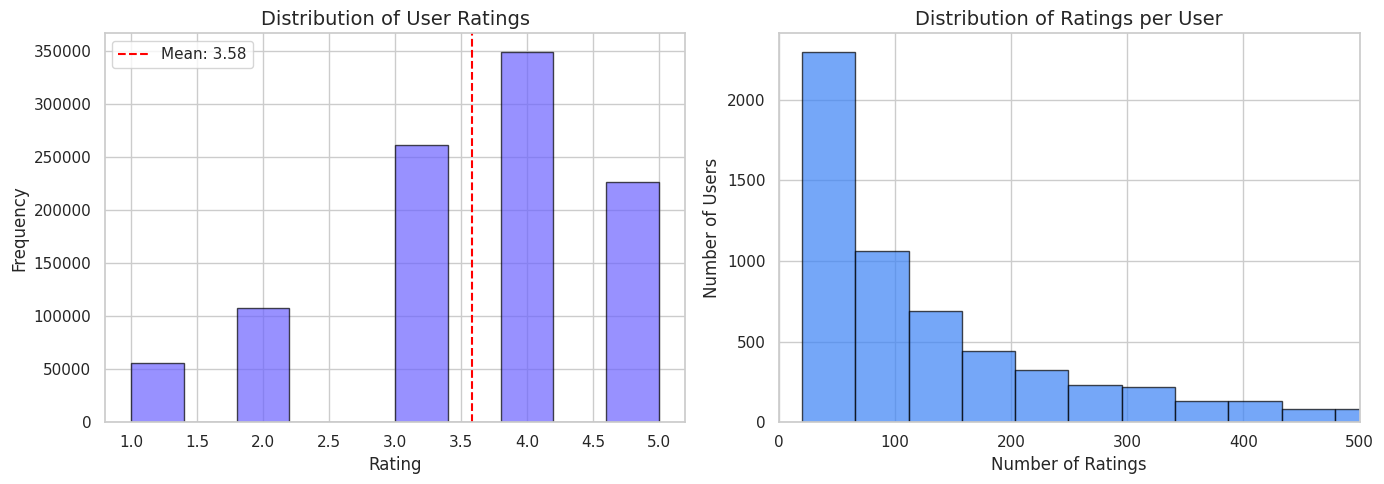

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
axes[0].hist(ratings_df['user_rating'], bins=10, edgecolor='black',
             alpha=0.7, color='#6c63ff')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of User Ratings')
mean_rating = ratings_df['user_rating'].mean()
axes[0].axvline(mean_rating, color='red', linestyle='--',
                label='Mean: {:.2f}'.format(mean_rating))
axes[0].legend()

# Ratings per user distribution
ratings_per_user = ratings_df.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=50, edgecolor='black',
             alpha=0.7, color='#3b82f6')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Distribution of Ratings per User')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

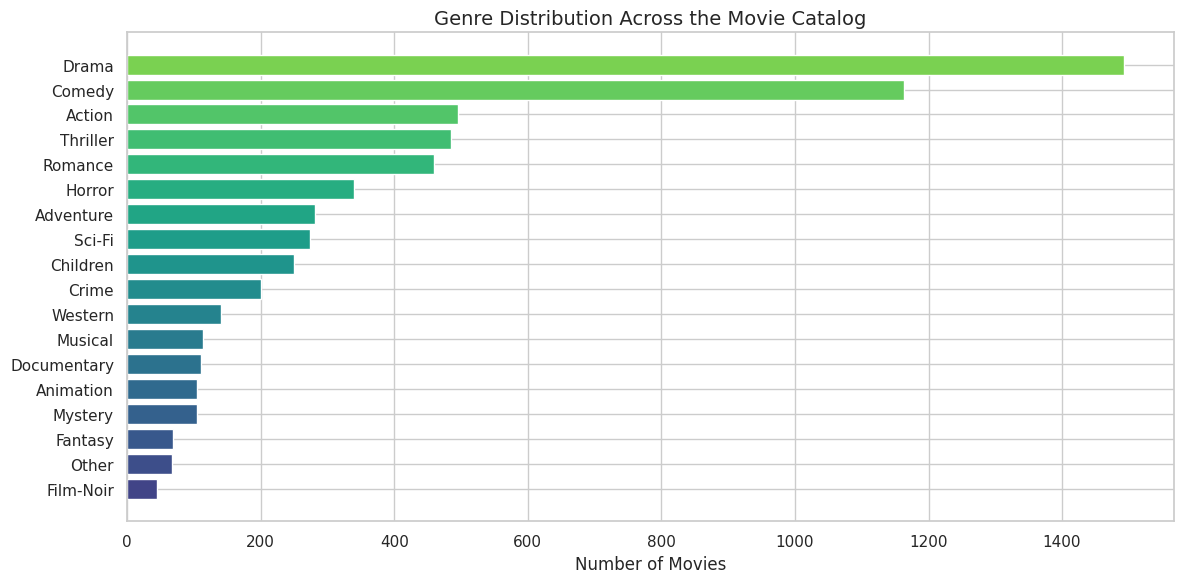

Top 15 Movies (minimum 100 ratings):
  4.56  ( 628 ratings)  Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)
         Genres: Action | Drama
  4.55  (2227 ratings)  Shawshank Redemption, The (1994)
         Genres: Drama
  4.52  (2223 ratings)  Godfather, The (1972)
         Genres: Action | Crime | Drama
  4.52  ( 657 ratings)  Close Shave, A (1995)
         Genres: Animation | Comedy | Thriller
  4.52  (1783 ratings)  Usual Suspects, The (1995)
         Genres: Crime | Thriller
  4.51  (2304 ratings)  Schindler's List (1993)
         Genres: Drama | Western
  4.51  ( 882 ratings)  Wrong Trousers, The (1993)
         Genres: Animation | Comedy
  4.49  ( 470 ratings)  Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
         Genres: Film-Noir
  4.48  (2514 ratings)  Raiders of the Lost Ark (1981)
         Genres: Action | Adventure
  4.48  (1050 ratings)  Rear Window (1954)
         Genres: Mystery | Thriller
  4.47  ( 230 ratings)  Paths of Glory (1957)
         Genre

In [ ]:
# Genre popularity across the movie catalog
all_genres = []
for genres_str in movies_df['genres_readable']:
    for genre in genres_str.split(' | '):
        genre = genre.strip()
        if genre and genre != 'Unknown':
            all_genres.append(genre)

genre_counts = pd.Series(all_genres).value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(genre_counts)))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors)
ax.set_xlabel('Number of Movies')
ax.set_title('Genre Distribution Across the Movie Catalog')
plt.tight_layout()
plt.show()

# Top-rated movies (with minimum rating count threshold)
movie_stats_eda = ratings_df.groupby('movie_id').agg(
    avg_rating=('user_rating', 'mean'),
    num_ratings=('user_rating', 'count')
).reset_index()

top_movies = movie_stats_eda[movie_stats_eda['num_ratings'] >= 100].nlargest(15, 'avg_rating')
top_movies = top_movies.merge(
    movies_df[['movie_id', 'movie_title', 'genres_readable']], on='movie_id'
)

print("Top 15 Movies (minimum 100 ratings):")
print("=" * 80)
for _, row in top_movies.iterrows():
    print("  {:.2f}  ({:>4} ratings)  {}".format(
        row['avg_rating'], row['num_ratings'], row['movie_title']))
    print("         Genres: {}".format(row['genres_readable']))

---
## 3. Utility Matrix Construction

The **Utility Matrix** $U$ is the foundational data structure for collaborative filtering. It is a matrix where:

- Each **row** represents a user ($x$).
- Each **column** represents a movie (item $i$).
- Each **entry** $r_{xi}$ is the rating that user $x$ gave to item $i$.

Since most users have only rated a small fraction of all available movies, this matrix is extremely **sparse**. We use `scipy.sparse.coo_matrix` for memory-efficient construction and then convert to CSR format for efficient row-slicing.

The sparsity percentage quantifies the proportion of unknown entries:

$$\text{Sparsity (\%)} = \left(1 - \frac{\text{Number of Ratings}}{\text{Number of Users} \times \text{Number of Movies}}\right) \times 100$$

In [ ]:
# Create contiguous index mappings (IDs may not be sequential)
user_ids = sorted(ratings_df['user_id'].unique())
movie_ids = sorted(ratings_df['movie_id'].unique())

user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}
idx_to_movie = {i: mid for mid, i in movie_to_idx.items()}

n_users = len(user_ids)
n_movies = len(movie_ids)

# Map IDs to matrix indices
row_indices = ratings_df['user_id'].map(user_to_idx).values
col_indices = ratings_df['movie_id'].map(movie_to_idx).values
rating_values = ratings_df['user_rating'].values.astype(np.float32)

# Construct the sparse utility matrix (COO format for construction)
utility_matrix_coo = coo_matrix(
    (rating_values, (row_indices, col_indices)),
    shape=(n_users, n_movies)
)

# Convert to CSR for efficient row-level access
utility_matrix_csr = utility_matrix_coo.tocsr()

# Calculate and display sparsity
total_entries = n_users * n_movies
filled_entries = utility_matrix_coo.nnz
sparsity = (1 - filled_entries / total_entries) * 100

print("Utility Matrix Dimensions: {:,} users x {:,} movies".format(n_users, n_movies))
print("Total Possible Entries:    {:,}".format(total_entries))
print("Filled Entries (Ratings):  {:,}".format(filled_entries))
print("Matrix Sparsity:           {:.2f}%".format(sparsity))
print()
print("Sparse Matrix Format: {}".format(utility_matrix_csr.format.upper()))
print("Memory Usage (Sparse): {:.1f} KB".format(utility_matrix_csr.data.nbytes / 1024))
print("Memory Usage (Dense):  {:.1f} MB".format(n_users * n_movies * 4 / (1024**2)))

Utility Matrix Dimensions: 6,040 users x 3,706 movies
Total Possible Entries:    22,384,240
Filled Entries (Ratings):  1,000,209
Matrix Sparsity:           95.53%

Sparse Matrix Format: CSR
Memory Usage (Sparse): 3907.1 KB
Memory Usage (Dense):  85.4 MB


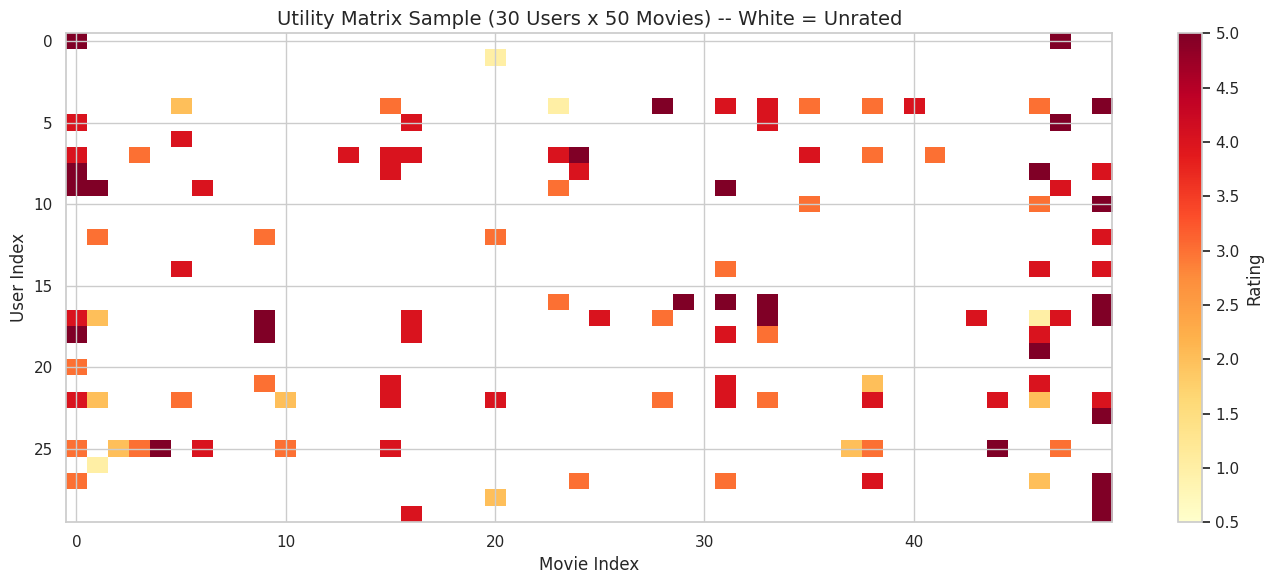

In [ ]:
# Visualize a small slice of the utility matrix
sample_u = 30
sample_m = 50
sample_slice = utility_matrix_csr[:sample_u, :sample_m].toarray()

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.YlOrRd.copy()
cmap.set_under('white')
im = ax.imshow(sample_slice, aspect='auto', cmap=cmap,
               vmin=0.5, vmax=5, interpolation='nearest')
ax.set_xlabel('Movie Index')
ax.set_ylabel('User Index')
ax.set_title('Utility Matrix Sample ({} Users x {} Movies) -- White = Unrated'.format(
    sample_u, sample_m))
plt.colorbar(im, ax=ax, label='Rating')
plt.tight_layout()
plt.show()

---
## 4. Item-Item Collaborative Filtering

Item-Item Collaborative Filtering works on the principle that **similar items receive similar ratings**. Rather than finding similar users (User-User CF), we find items that have been rated similarly by the same set of users.

### 4.1 Data Centering (Bias Removal)

Users have different baseline rating tendencies. A "generous" user might rate most movies 4--5, while a "critical" user rates them 2--3. To account for this bias, we **center** the data by subtracting each user's mean rating from their entries.

For user $x$ with mean rating $\bar{r}_x$, the centered rating for item $i$ is:

$$\hat{r}_{xi} = r_{xi} - \bar{r}_x$$

This ensures that the similarity computation focuses on the **relative preference** signal, not the absolute rating scale.

In [ ]:
# Convert to dense for centering (~89 MB, feasible for Colab)
utility_dense = utility_matrix_csr.toarray().astype(np.float64)

# Compute per-user mean ratings (over rated items only)
user_means = np.zeros(n_users)
for i in range(n_users):
    rated_mask = utility_dense[i, :] > 0
    if rated_mask.sum() > 0:
        user_means[i] = utility_dense[i, rated_mask].mean()

# Center the matrix: subtract user mean from each rated entry
centered_matrix = utility_dense.copy()
for i in range(n_users):
    rated_mask = centered_matrix[i, :] != 0
    centered_matrix[i, rated_mask] -= user_means[i]

print("Data centering complete.")
print("Sample user mean ratings (first 10 users):")
print(np.round(user_means[:10], 2))
print("Global average rating: {:.3f}".format(user_means[user_means > 0].mean()))

Data centering complete.
Sample user mean ratings (first 10 users):
[4.19 3.71 3.9  4.19 3.15 3.9  4.32 3.88 3.74 4.11]
Global average rating: 3.703


### 4.2 Pearson Correlation Coefficient as Similarity Metric

The similarity between two items $i$ and $j$ is computed using the **Pearson Correlation Coefficient**. This measures the linear correlation between their centered rating vectors across all users who rated both items.

$$s_{ij} = \frac{\sum_{x \in S_{ij}} (r_{xi} - \bar{r}_x)(r_{xj} - \bar{r}_x)}{\sqrt{\sum_{x \in S_{ij}} (r_{xi} - \bar{r}_x)^2} \cdot \sqrt{\sum_{x \in S_{ij}} (r_{xj} - \bar{r}_x)^2}}$$

where $S_{ij}$ is the set of users who have rated both items $i$ and $j$.

**Implementation note:** Computing cosine similarity on the **centered** rating matrix is mathematically equivalent to Pearson Correlation. This allows us to leverage Scikit-learn's optimized `cosine_similarity` function on sparse matrix representations.

In [ ]:
# Transpose the centered matrix so items are rows, users are columns
# Shape: (n_movies, n_users)
centered_sparse = csr_matrix(centered_matrix)
item_vectors = centered_sparse.T

# Compute item-item similarity (Pearson via cosine on centered data)
print("Computing item-item similarity matrix...")
t_start = time.time()
item_similarity = cosine_similarity(item_vectors)
elapsed = time.time() - t_start

# An item should not be its own neighbor
np.fill_diagonal(item_similarity, 0)

print("Item-Item Similarity Matrix Shape: {}".format(item_similarity.shape))
print("Computation Time: {:.2f} seconds".format(elapsed))
print("Memory Usage: {:.1f} MB".format(item_similarity.nbytes / (1024**2)))

# Similarity statistics
nonzero_sims = item_similarity[item_similarity != 0]
print()
print("Similarity statistics (non-zero entries):")
print("  Count: {:,}".format(len(nonzero_sims)))
print("  Mean:  {:.4f}".format(nonzero_sims.mean()))
print("  Std:   {:.4f}".format(nonzero_sims.std()))
print("  Min:   {:.4f}".format(nonzero_sims.min()))
print("  Max:   {:.4f}".format(nonzero_sims.max()))

Computing item-item similarity matrix...
Item-Item Similarity Matrix Shape: (3706, 3706)
Computation Time: 1.76 seconds
Memory Usage: 104.8 MB

Similarity statistics (non-zero entries):
  Count: 11,309,582
  Mean:  0.0010
  Std:   0.0466
  Min:   -1.0000
  Max:   1.0000


### 4.3 Prediction Function

To predict the rating $r_{xi}$ that user $x$ would give to item $i$, we use a **weighted average** of the user's existing ratings on the $k$ most similar items (neighbors):

$$r_{xi} = \frac{\sum_{j \in N(i;x)} s_{ij} \cdot r_{xj}}{\sum_{j \in N(i;x)} s_{ij}}$$

where:
- $N(i;x)$ is the set of top-$k$ items most similar to $i$ that user $x$ has actually rated.
- $s_{ij}$ is the Pearson similarity between items $i$ and $j$.
- $r_{xj}$ is the actual rating user $x$ gave to item $j$.

Only neighbors with **positive similarity** ($s_{ij} > 0$) are considered, to avoid noise from negatively correlated items.

In [ ]:
def predict_rating(user_idx, movie_idx, k=10):
    """
    Predict the rating for a user-movie pair using item-item
    collaborative filtering with weighted average of k neighbors.

    Parameters:
        user_idx:  Index of the user in the utility matrix.
        movie_idx: Index of the movie in the utility matrix.
        k:         Number of nearest neighbors to consider.

    Returns:
        Predicted rating, clamped to [1.0, 5.0].
    """
    # Get the user's original ratings
    user_ratings = utility_matrix_csr[user_idx, :].toarray().ravel()
    rated_items = np.where(user_ratings > 0)[0]

    # Fallback: if no ratings exist, return user mean or global default
    if len(rated_items) == 0:
        return user_means[user_idx] if user_means[user_idx] > 0 else 3.0

    # Similarities between target movie and each rated item
    similarities = item_similarity[movie_idx, rated_items]

    # Select top-k neighbors by similarity magnitude
    if len(similarities) > k:
        top_k_indices = np.argsort(similarities)[-k:]
    else:
        top_k_indices = np.arange(len(similarities))

    top_k_sims = similarities[top_k_indices]
    top_k_ratings = user_ratings[rated_items[top_k_indices]]

    # Keep only positive-similarity neighbors
    positive_mask = top_k_sims > 0
    if positive_mask.sum() == 0:
        return user_means[user_idx] if user_means[user_idx] > 0 else 3.0

    top_k_sims = top_k_sims[positive_mask]
    top_k_ratings = top_k_ratings[positive_mask]

    # Weighted average: r_xi = sum(s_ij * r_xj) / sum(s_ij)
    predicted = np.dot(top_k_sims, top_k_ratings) / top_k_sims.sum()

    return float(np.clip(predicted, 1.0, 5.0))


# --- Test the prediction function ---
test_user_id = user_ids[0]
test_user_idx = user_to_idx[test_user_id]

# Find a movie this user has NOT rated
user_rated = utility_matrix_csr[test_user_idx, :].toarray().ravel()
unrated_indices = np.where(user_rated == 0)[0]

if len(unrated_indices) > 0:
    test_movie_idx = unrated_indices[0]
    test_movie_id = idx_to_movie[test_movie_idx]
    match = movies_df[movies_df['movie_id'] == test_movie_id]
    title = match['movie_title'].values[0] if not match.empty else "Unknown"
    predicted = predict_rating(test_user_idx, test_movie_idx)
    print("Test: Predicting rating for User {} on '{}'".format(test_user_id, title))
    print("Predicted Rating: {:.2f}".format(predicted))

Test: Predicting rating for User 1 on 'Jumanji (1995)'
Predicted Rating: 3.61


In [ ]:
def get_cf_recommendations(user_id, n=10, k=10):
    """
    Generate top-N movie recommendations for an existing user
    using Item-Item Collaborative Filtering.
    """
    if user_id not in user_to_idx:
        print("User {} not found in the dataset.".format(user_id))
        return pd.DataFrame()

    user_idx = user_to_idx[user_id]
    user_ratings = utility_matrix_csr[user_idx, :].toarray().ravel()
    unrated_items = np.where(user_ratings == 0)[0]

    # Predict rating for every unrated movie
    predictions = []
    for movie_idx in unrated_items:
        pred = predict_rating(user_idx, movie_idx, k=k)
        predictions.append((movie_idx, pred))

    # Sort by predicted rating (descending)
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_predictions = predictions[:n]

    # Build results dataframe
    results = []
    for movie_idx, pred_rating in top_predictions:
        movie_id = idx_to_movie[movie_idx]
        movie_row = movies_df[movies_df['movie_id'] == movie_id]
        if not movie_row.empty:
            results.append({
                'movie_title': movie_row['movie_title'].values[0],
                'predicted_rating': round(pred_rating, 2),
                'genres': movie_row['genres_readable'].values[0],
                'poster_url': movie_row['poster_url'].values[0]
            })

    return pd.DataFrame(results)


# --- Demo ---
demo_user_id = user_ids[100]
print("Collaborative Filtering Recommendations for User {}:".format(demo_user_id))
print("=" * 80)

cf_recs = get_cf_recommendations(demo_user_id, n=10)
for i, (_, row) in enumerate(cf_recs.iterrows(), 1):
    print("  {:>2}. [{:.2f}] {}".format(i, row['predicted_rating'], row['movie_title']))
    print("      Genres: {}".format(row['genres']))

Collaborative Filtering Recommendations for User 101:
   1. [5.00] Tom and Huck (1995)
      Genres: Adventure | Children
   2. [5.00] It Takes Two (1995)
      Genres: Comedy
   3. [5.00] Black Sheep (1996)
      Genres: Comedy
   4. [5.00] Beautiful Girls (1996)
      Genres: Drama
   5. [5.00] Nueba Yol (1995)
      Genres: Comedy | Drama
   6. [5.00] Neon Bible, The (1995)
      Genres: Drama
   7. [5.00] Shadows (Cienie) (1988)
      Genres: Drama
   8. [5.00] Blue in the Face (1995)
      Genres: Comedy
   9. [5.00] Nine Months (1995)
      Genres: Comedy
  10. [5.00] Billy Madison (1995)
      Genres: Comedy


---
## 5. Content-Based Filtering (Cold Start Solution)

Content-Based Filtering addresses the **Cold Start Problem**: recommending items to new users who have no rating history. Instead of relying on collaborative signals, it matches items based on their intrinsic features.

### 5.1 TF-IDF Item Profiles

Each movie is represented as a feature vector based on its genres using **TF-IDF (Term Frequency -- Inverse Document Frequency)**:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

where:
- $\text{TF}(t, d)$ = frequency of term $t$ in document $d$
- $\text{IDF}(t) = \log\frac{N}{n_t}$, with $N$ = total number of documents (movies) and $n_t$ = number of documents containing term $t$

### 5.2 Cosine Similarity

The similarity between two movie profile vectors $A$ and $B$ is measured using **Cosine Similarity**:

$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \cdot \sqrt{\sum_{i=1}^{n} B_i^2}}$$

In [ ]:
# Prepare genre tokens for TF-IDF vectorization
def genres_to_tokens(genre_codes_str):
    """Convert numeric genre codes to space-separated tokens."""
    codes = str(genre_codes_str).split(',')
    tokens = []
    for code in codes:
        code = code.strip()
        if code.isdigit():
            name = GENRE_MAP.get(int(code), 'Unknown')
            # Remove special characters for clean tokenization
            tokens.append(name.replace("'", "").replace(" ", "").replace("-", ""))
    return ' '.join(tokens) if tokens else 'Unknown'

movies_df['genre_tokens'] = movies_df['movie_genres'].apply(genres_to_tokens)

# Build TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(movies_df['genre_tokens'])

print("TF-IDF Matrix Shape: {}".format(tfidf_matrix.shape))
print("Feature Names (Genre Tokens): {}".format(
    tfidf_vectorizer.get_feature_names_out()))

# Compute pairwise cosine similarity between all movies
content_similarity = cosine_similarity(tfidf_matrix, tfidf_matrix)
np.fill_diagonal(content_similarity, 0)

print("Content Similarity Matrix Shape: {}".format(content_similarity.shape))

TF-IDF Matrix Shape: (3706, 18)
Feature Names (Genre Tokens): ['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'filmnoir' 'horror' 'musical' 'mystery'
 'romance' 'scifi' 'thriller' 'unknown' 'western']
Content Similarity Matrix Shape: (3706, 3706)


In [ ]:
# Build a lookup from movie title to DataFrame row index
movie_title_to_df_idx = {
    title: idx for idx, title in enumerate(movies_df['movie_title'].values)
}

def get_content_recommendations(movie_title, n=10):
    """
    Get content-based recommendations using cosine similarity
    on TF-IDF genre vectors. Works without user rating data (Cold Start).
    """
    if movie_title not in movie_title_to_df_idx:
        print("Movie '{}' not found in the catalog.".format(movie_title))
        # Try partial match
        matches = [t for t in movie_title_to_df_idx if movie_title.lower() in t.lower()]
        if matches:
            print("Did you mean one of these?")
            for m in matches[:5]:
                print("  - {}".format(m))
        return pd.DataFrame()

    idx = movie_title_to_df_idx[movie_title]
    sim_scores = content_similarity[idx]
    top_indices = np.argsort(sim_scores)[::-1][:n]

    results = movies_df.iloc[top_indices][
        ['movie_title', 'genres_readable', 'poster_url']
    ].copy()
    results['similarity_score'] = np.round(sim_scores[top_indices], 4)
    results = results.reset_index(drop=True)
    return results


# --- Demo ---
# Use first movie in the catalog as seed (robust fallback)
seed_movie = "Toy Story (1995)"
if seed_movie not in movie_title_to_df_idx:
    seed_movie = movies_df['movie_title'].values[0]

print("Content-Based Recommendations similar to '{}':".format(seed_movie))
print("=" * 80)
content_recs = get_content_recommendations(seed_movie, n=10)
if not content_recs.empty:
    for i, (_, row) in enumerate(content_recs.iterrows(), 1):
        print("  {:>2}. [Score: {:.4f}] {}".format(
            i, row['similarity_score'], row['movie_title']))
        print("      Genres: {}".format(row['genres_readable']))

Content-Based Recommendations similar to 'Toy Story (1995)':
   1. [Score: 1.0000] Saludos Amigos (1943)
      Genres: Animation | Children | Comedy
   2. [Score: 1.0000] American Tail: Fievel Goes West, An (1991)
      Genres: Animation | Children | Comedy
   3. [Score: 1.0000] Adventures of Rocky and Bullwinkle, The (2000)
      Genres: Animation | Children | Comedy
   4. [Score: 1.0000] Chicken Run (2000)
      Genres: Animation | Children | Comedy
   5. [Score: 1.0000] Aladdin and the King of Thieves (1996)
      Genres: Animation | Children | Comedy
   6. [Score: 1.0000] Rugrats Movie, The (1998)
      Genres: Animation | Children | Comedy
   7. [Score: 1.0000] Bug's Life, A (1998)
      Genres: Animation | Children | Comedy
   8. [Score: 1.0000] Toy Story 2 (1999)
      Genres: Animation | Children | Comedy
   9. [Score: 1.0000] American Tail, An (1986)
      Genres: Animation | Children | Comedy
  10. [Score: 0.9384] Rescuers Down Under, The (1990)
      Genres: Animation | Chil

---
## 6. Hybrid Recommendation Strategy

The hybrid approach combines Content-Based and Collaborative Filtering to handle different user scenarios:

| Scenario | Strategy | Method |
|---|---|---|
| **New User** (no ratings) | Simple Aggregates + Content-Based | Show "Top Popular" movies and content-based recommendations from a search query. |
| **Sparse User** (< 5 ratings) | Blend CF + Aggregates | Supplement limited CF predictions with popular titles. |
| **Existing User** (>= 5 ratings) | Full Collaborative Filtering | Personalized predictions using Item-Item CF. |

The engine also identifies **"Hidden Gems"** from the **Long Tail**: movies with few ratings but exceptionally high average quality. These are explicitly surfaced to drive users beyond mainstream content.

In [ ]:
def get_trending_movies(n=10):
    """
    Get top movies by popularity (Simple Aggregates).
    Applies a minimum rating count threshold to filter noise.
    """
    movie_stats = ratings_df.groupby('movie_id').agg(
        avg_rating=('user_rating', 'mean'),
        num_ratings=('user_rating', 'count')
    ).reset_index()

    popular = movie_stats[
        (movie_stats['num_ratings'] >= 100) &
        (movie_stats['avg_rating'] >= 3.5)
    ].sort_values('num_ratings', ascending=False).head(n)

    result = popular.merge(
        movies_df[['movie_id', 'movie_title', 'genres_readable', 'poster_url']],
        on='movie_id'
    )
    result['avg_rating'] = result['avg_rating'].round(2)
    return result[['movie_title', 'avg_rating', 'num_ratings',
                    'genres_readable', 'poster_url']]


def get_hidden_gems(n=10):
    """
    Identify 'Long Tail' movies: low popularity but high average rating.
    These Hidden Gems are high-quality content overlooked by the mainstream.
    """
    movie_stats = ratings_df.groupby('movie_id').agg(
        avg_rating=('user_rating', 'mean'),
        num_ratings=('user_rating', 'count')
    ).reset_index()

    gems = movie_stats[
        (movie_stats['num_ratings'] >= 5) &
        (movie_stats['num_ratings'] <= 50) &
        (movie_stats['avg_rating'] >= 4.0)
    ].sort_values('avg_rating', ascending=False).head(n)

    result = gems.merge(
        movies_df[['movie_id', 'movie_title', 'genres_readable', 'poster_url']],
        on='movie_id'
    )
    result['avg_rating'] = result['avg_rating'].round(2)
    return result[['movie_title', 'avg_rating', 'num_ratings',
                    'genres_readable', 'poster_url']]


def hybrid_recommend(user_id, n=10):
    """
    Hybrid recommendation engine that automatically selects the
    best strategy based on the user's profile.

    - New User:    Simple Aggregates (Cold Start fallback)
    - Sparse User: Blend of CF + Aggregates
    - Active User: Full Item-Item Collaborative Filtering
    """
    # Cold start: unknown user
    if user_id not in user_to_idx:
        print("[COLD START] User {} is new. Returning popular titles.".format(user_id))
        return get_trending_movies(n)

    user_idx = user_to_idx[user_id]
    user_ratings = utility_matrix_csr[user_idx, :].toarray().ravel()
    n_rated = int((user_ratings > 0).sum())

    # Sparse user
    if n_rated < 5:
        print("[SPARSE] User {} has only {} ratings. Blending CF + Popular.".format(
            user_id, n_rated))
        cf_count = max(n // 2, 1)
        pop_count = n - cf_count
        cf_recs = get_cf_recommendations(user_id, n=cf_count)
        popular = get_trending_movies(pop_count)
        return pd.concat([cf_recs, popular], ignore_index=True)

    # Active user
    print("[PERSONALIZED] User {} has {} ratings. Using full CF engine.".format(
        user_id, n_rated))
    return get_cf_recommendations(user_id, n=n)

In [ ]:
# --- Demo: Hybrid Strategy ---
print("=" * 80)
print("DEMO: Hybrid Recommendation Strategy")
print("=" * 80)

# Case 1: Active existing user
demo_active = user_ids[50]
print()
print("--- Case 1: Active User (ID: {}) ---".format(demo_active))
recs_active = hybrid_recommend(demo_active, n=5)
display(recs_active)

# Case 2: Simulate a completely new user (cold start)
print()
print("--- Case 2: New User (ID: 99999) ---")
recs_new = hybrid_recommend(99999, n=5)
display(recs_new)

# Case 3: Hidden Gems
print()
print("--- Hidden Gems from the Long Tail ---")
gems = get_hidden_gems(10)
display(gems)

DEMO: Hybrid Recommendation Strategy

--- Case 1: Active User (ID: 51) ---
[PERSONALIZED] User 51 has 40 ratings. Using full CF engine.


,movie_title,predicted_rating,genres,poster_url
0,"Loves of Carmen, The (1948)",5.00,Drama,https://image.tmdb.org/t/p/w500/q6zuGR1lyWDRaB...
1,Project Moon Base (1953),5.00,Sci-Fi,https://image.tmdb.org/t/p/w500/djG5ljYkjESdye...
2,Relative Fear (1994),4.90,Horror | Thriller,https://image.tmdb.org/t/p/w500/wG6wdsB9lqCwxs...
3,"Crude Oasis, The (1995)",4.82,Romance,https://image.tmdb.org/t/p/w500/1FrbZeFn5yhjls...
4,Intimate Relations (1996),4.70,Comedy,https://image.tmdb.org/t/p/w500/xTIS7xKJRpyrE5...



--- Case 2: New User (ID: 99999) ---
[COLD START] User 99999 is new. Returning popular titles.


,movie_title,avg_rating,num_ratings,genres_readable,poster_url
0,American Beauty (1999),4.32,3428,Comedy | Drama,https://image.tmdb.org/t/p/w500/s5PXkDqS8W3K4w...
1,Star Wars: Episode IV - A New Hope (1977),4.45,2991,Action | Adventure | Fantasy | Sci-Fi,https://image.tmdb.org/t/p/w500/6FfCtAuVAW8XJj...
2,Star Wars: Episode V - The Empire Strikes Back...,4.29,2990,Action | Adventure | Drama | Sci-Fi | Western,https://image.tmdb.org/t/p/w500/9ldJDAUVPpFyod...
3,Star Wars: Episode VI - Return of the Jedi (1983),4.02,2883,Action | Adventure | Romance | Sci-Fi | Western,https://image.tmdb.org/t/p/w500/jQYlydvHm3kUix...
4,Jurassic Park (1993),3.76,2672,Action | Adventure | Sci-Fi,https://image.tmdb.org/t/p/w500/fjTU1Bgh3KJu4a...



--- Hidden Gems from the Long Tail ---


,movie_title,avg_rating,num_ratings,genres_readable,poster_url
0,I Am Cuba (Soy Cuba/Ya Kuba) (1964),4.80,5,Drama,https://image.tmdb.org/t/p/w500/yjkqAhn3hdO7PI...
1,Lamerica (1994),4.75,8,Drama,https://image.tmdb.org/t/p/w500/nnLpA4mqb3gvhN...
2,"Apple, The (Sib) (1998)",4.67,9,Drama,https://image.tmdb.org/t/p/w500/9EnutQg30a9r2t...
3,For All Mankind (1989),4.44,27,Documentary,https://image.tmdb.org/t/p/w500/7k8ylisWiEGxdR...
4,Pather Panchali (1955),4.40,47,Drama,https://image.tmdb.org/t/p/w500/frZj5djlU9hFEj...
5,Return with Honor (1998),4.40,5,Documentary,https://image.tmdb.org/t/p/w500/8QGF0PtMlTK1cU...
6,Hearts and Minds (1996),4.36,14,Drama,https://image.tmdb.org/t/p/w500/yXnpP2RAZbG3DQ...
7,Jupiter's Wife (1994),4.33,12,Documentary,https://image.tmdb.org/t/p/w500/2GIdaPLF7gYyXn...
8,Soft Fruit (1999),4.33,9,Comedy | Drama,https://image.tmdb.org/t/p/w500/eaOehKsttNGjoa...
9,Time of the Gypsies (Dom za vesanje) (1989),4.30,10,Drama,https://image.tmdb.org/t/p/w500/fF9kWNMjiXC6f4...


---
## 7. Model Evaluation (RMSE)

To evaluate the accuracy of our collaborative filtering predictions, we use **Root-Mean-Square Error (RMSE)**. A lower RMSE indicates predictions closer to the actual user ratings.

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{r}_i - r_i)^2}$$

where:
- $\hat{r}_i$ = predicted rating for the $i$-th test sample
- $r_i$ = actual rating
- $n$ = number of test samples

**Methodology:**
1. Split the ratings data into an 80% training set and a 20% test set.
2. Rebuild the utility matrix and item similarity matrix using the training data only.
3. Predict ratings for entries in the test set using the training-only model.
4. Compute RMSE over the predictions.

In [ ]:
print("--- Phase 1: Train/Test Split ---")
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)
print("Training samples: {:,}".format(len(train_df)))
print("Test samples:     {:,}".format(len(test_df)))

print()
print("--- Phase 2: Rebuilding Model on Training Data ---")
t_start = time.time()

# Build training utility matrix
train_row = train_df['user_id'].map(user_to_idx).values
train_col = train_df['movie_id'].map(movie_to_idx).values
train_data = train_df['user_rating'].values.astype(np.float64)

train_matrix_csr = coo_matrix(
    (train_data, (train_row, train_col)),
    shape=(n_users, n_movies)
).tocsr()

# Training user means
train_dense = train_matrix_csr.toarray()
train_user_means = np.zeros(n_users)
for i in range(n_users):
    rated_mask = train_dense[i, :] > 0
    if rated_mask.sum() > 0:
        train_user_means[i] = train_dense[i, rated_mask].mean()

# Center training data
train_centered = train_dense.copy()
for i in range(n_users):
    rated_mask = train_centered[i, :] != 0
    train_centered[i, rated_mask] -= train_user_means[i]

# Training item similarity
train_item_sim = cosine_similarity(csr_matrix(train_centered).T)
np.fill_diagonal(train_item_sim, 0)

elapsed = time.time() - t_start
print("Training model rebuilt in {:.1f} seconds.".format(elapsed))

print()
print("--- Phase 3: Predicting Test Ratings ---")

EVAL_SAMPLE_SIZE = 5000
test_sample = test_df.sample(
    n=min(EVAL_SAMPLE_SIZE, len(test_df)), random_state=42
)
print("Evaluating on {:,} sampled test entries...".format(len(test_sample)))

actuals = []
predictions = []
k_eval = 10

t_start = time.time()
for count, (_, row) in enumerate(test_sample.iterrows(), 1):
    u_idx = user_to_idx[row['user_id']]
    m_idx = movie_to_idx[row['movie_id']]

    u_ratings = train_matrix_csr[u_idx, :].toarray().ravel()
    rated_items = np.where(u_ratings > 0)[0]

    if len(rated_items) == 0:
        pred = train_user_means[u_idx] if train_user_means[u_idx] > 0 else 3.0
    else:
        sims = train_item_sim[m_idx, rated_items]
        if len(sims) > k_eval:
            top_k = np.argsort(sims)[-k_eval:]
        else:
            top_k = np.arange(len(sims))

        top_sims = sims[top_k]
        top_ratings = u_ratings[rated_items[top_k]]

        pos_mask = top_sims > 0
        if pos_mask.sum() == 0:
            pred = train_user_means[u_idx] if train_user_means[u_idx] > 0 else 3.0
        else:
            pred = np.dot(top_sims[pos_mask], top_ratings[pos_mask]) / top_sims[pos_mask].sum()

    pred = float(np.clip(pred, 1.0, 5.0))
    actuals.append(row['user_rating'])
    predictions.append(pred)

    if count % 1000 == 0:
        print("  Processed {:,}/{:,} samples...".format(count, len(test_sample)))

elapsed = time.time() - t_start
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = np.mean(np.abs(np.array(actuals) - np.array(predictions)))

print()
print("=" * 50)
print("EVALUATION RESULTS ({:,} test samples)".format(len(test_sample)))
print("=" * 50)
print("  RMSE:            {:.4f}".format(rmse))
print("  MAE:             {:.4f}".format(mae))
print("  k (neighbors):   {}".format(k_eval))
print("  Eval Time:       {:.1f} seconds".format(elapsed))
print("=" * 50)

--- Phase 1: Train/Test Split ---
Training samples: 800,167
Test samples:     200,042

--- Phase 2: Rebuilding Model on Training Data ---
Training model rebuilt in 2.2 seconds.

--- Phase 3: Predicting Test Ratings ---
Evaluating on 5,000 sampled test entries...
  Processed 1,000/5,000 samples...
  Processed 2,000/5,000 samples...
  Processed 3,000/5,000 samples...
  Processed 4,000/5,000 samples...
  Processed 5,000/5,000 samples...

EVALUATION RESULTS (5,000 test samples)
  RMSE:            0.8915
  MAE:             0.6922
  k (neighbors):   10
  Eval Time:       1.5 seconds


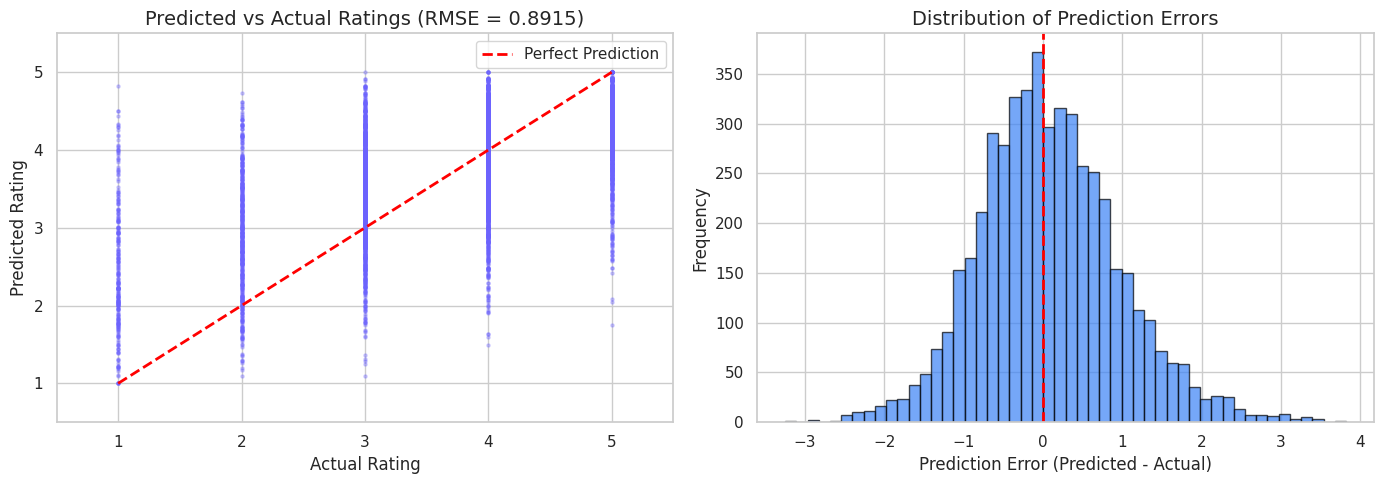

In [ ]:
# Predicted vs Actual Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(actuals, predictions, alpha=0.3, s=5, color='#6c63ff')
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('Predicted vs Actual Ratings (RMSE = {:.4f})'.format(rmse))
axes[0].legend()
axes[0].set_xlim(0.5, 5.5)
axes[0].set_ylim(0.5, 5.5)

# Error distribution
errors = np.array(predictions) - np.array(actuals)
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='#3b82f6')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Errors')

plt.tight_layout()
plt.show()

---
## 8. Visualizations and Analysis

### 8.1 The Long Tail Distribution

The "Long Tail" is a key concept in recommender systems. Most user activity concentrates on a small number of popular items (the "head"), while the vast majority of the catalog receives very few ratings (the "tail"). A well-designed recommendation engine guides users into this tail to discover valuable, otherwise-overlooked content.

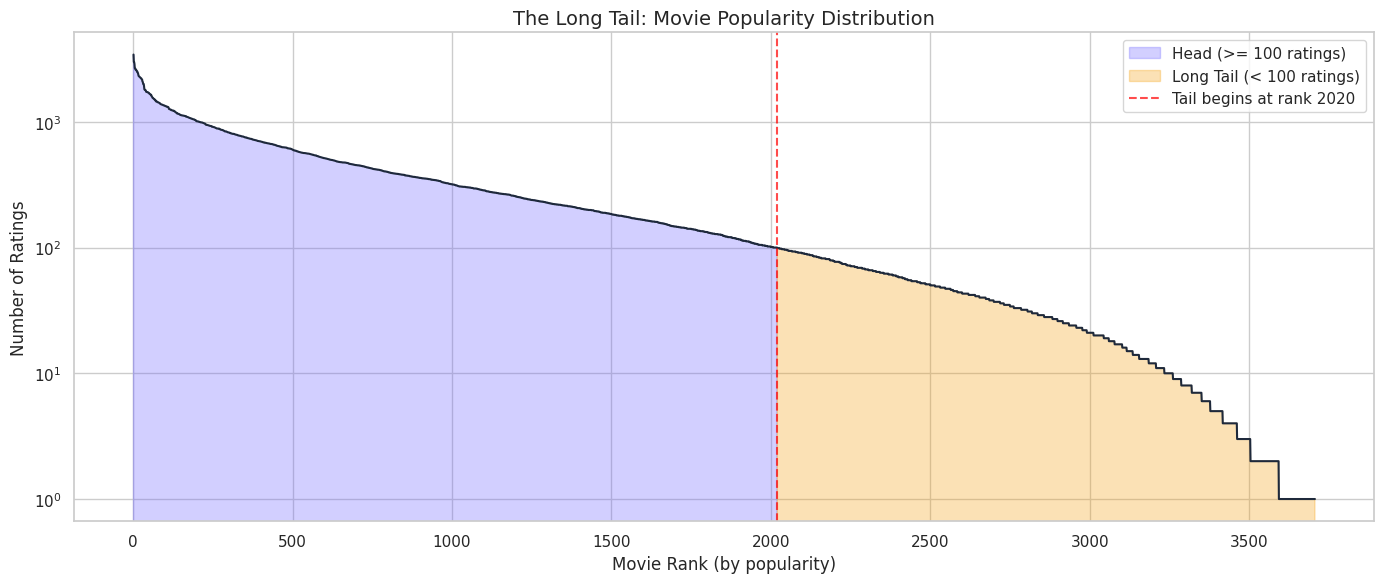

Head movies (>= 100 ratings): 2019 (54.5%)
Tail movies (< 100 ratings):  1687 (45.5%)


In [ ]:
# Long Tail: Movie popularity distribution
movie_popularity = (
    ratings_df.groupby('movie_id').size()
    .sort_values(ascending=False)
    .reset_index()
)
movie_popularity.columns = ['movie_id', 'num_ratings']
movie_popularity['rank'] = range(1, len(movie_popularity) + 1)

fig, ax = plt.subplots(figsize=(14, 6))

head_threshold = 100
tail_start_row = movie_popularity[movie_popularity['num_ratings'] < head_threshold]
tail_start = int(tail_start_row.iloc[0]['rank']) if not tail_start_row.empty else len(movie_popularity)

# Head region
ax.fill_between(
    movie_popularity['rank'], movie_popularity['num_ratings'],
    where=movie_popularity['rank'] < tail_start,
    alpha=0.3, color='#6c63ff',
    label='Head (>= {} ratings)'.format(head_threshold)
)

# Long tail region
ax.fill_between(
    movie_popularity['rank'], movie_popularity['num_ratings'],
    where=movie_popularity['rank'] >= tail_start,
    alpha=0.3, color='#f59e0b',
    label='Long Tail (< {} ratings)'.format(head_threshold)
)

ax.plot(movie_popularity['rank'], movie_popularity['num_ratings'],
        color='#1e293b', linewidth=1.5)
ax.axvline(x=tail_start, color='red', linestyle='--', alpha=0.7,
           label='Tail begins at rank {}'.format(tail_start))

ax.set_xlabel('Movie Rank (by popularity)')
ax.set_ylabel('Number of Ratings')
ax.set_title('The Long Tail: Movie Popularity Distribution')
ax.legend(fontsize=11)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

head_count = len(movie_popularity[movie_popularity['num_ratings'] >= head_threshold])
tail_count = len(movie_popularity[movie_popularity['num_ratings'] < head_threshold])
print("Head movies (>= {} ratings): {} ({:.1f}%)".format(
    head_threshold, head_count, head_count / len(movie_popularity) * 100))
print("Tail movies (< {} ratings):  {} ({:.1f}%)".format(
    head_threshold, tail_count, tail_count / len(movie_popularity) * 100))

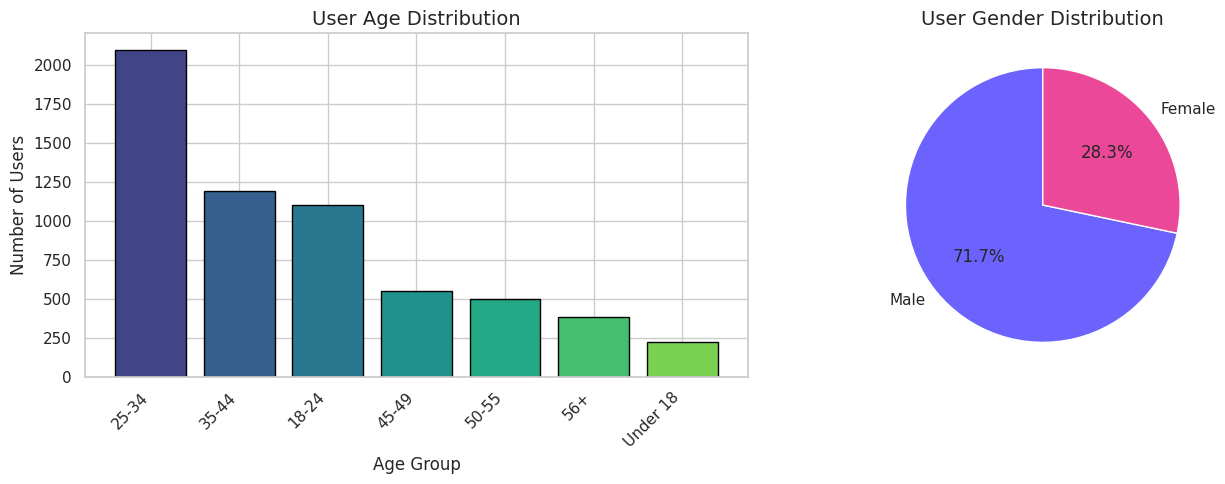

In [ ]:
# User Demographics Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
age_labels = {
    1.0: 'Under 18', 18.0: '18-24', 25.0: '25-34', 35.0: '35-44',
    45.0: '45-49', 50.0: '50-55', 56.0: '56+'
}
user_ages = users_df['bucketized_user_age'].map(age_labels).value_counts()
n_age_groups = len(user_ages)
colors_age = plt.cm.viridis(np.linspace(0.2, 0.8, n_age_groups))

axes[0].bar(range(n_age_groups), user_ages.values,
            color=colors_age, edgecolor='black')
axes[0].set_xticks(range(n_age_groups))
axes[0].set_xticklabels(user_ages.index, rotation=45, ha='right')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Age Distribution')

# Gender distribution
gender_map = {True: 'Male', False: 'Female'}
gender_counts = users_df['user_gender'].map(gender_map).value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#6c63ff', '#ec4899'], startangle=90)
axes[1].set_title('User Gender Distribution')

plt.tight_layout()
plt.show()

---
## 9. Streamlit Dashboard Prototype

This section saves all pre-computed model artifacts and writes a complete Streamlit application to `app.py`. The dashboard includes:

1. **Trending Now** -- Top popular movies from simple aggregates.
2. **Personalized Recommendations** -- CF-based recommendations for a selected user.
3. **Hidden Gems** -- Long Tail discoveries with high quality but low mainstream visibility.

### Running the Dashboard

**From Google Colab:**
```
!pip install streamlit -q
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501
```

**Locally:**
```
pip install streamlit
streamlit run app.py
```

In [ ]:
import pickle

# Save all model artifacts needed by the Streamlit dashboard
artifacts = {
    'movies_df': movies_df,
    'ratings_df': ratings_df,
    'item_similarity': item_similarity,
    'content_similarity': content_similarity,
    'utility_matrix_csr': utility_matrix_csr,
    'user_to_idx': user_to_idx,
    'movie_to_idx': movie_to_idx,
    'idx_to_user': idx_to_user,
    'idx_to_movie': idx_to_movie,
    'user_means': user_means,
    'n_users': n_users,
    'n_movies': n_movies,
    'GENRE_MAP': GENRE_MAP
}

with open('recommender_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

file_size = os.path.getsize('recommender_artifacts.pkl') / (1024**2)
print("Model artifacts saved to 'recommender_artifacts.pkl'")
print("File size: {:.1f} MB".format(file_size))

Model artifacts saved to 'recommender_artifacts.pkl'
File size: 256.2 MB


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# ------------------------------------------------------------------
# Page Configuration
# ------------------------------------------------------------------
st.set_page_config(
    page_title="Cinema Discovery Engine",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ------------------------------------------------------------------
# Custom CSS for a premium dark-themed UI
# ------------------------------------------------------------------
st.markdown(
    '''<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');

    html, body, [class*="css"] {
        font-family: 'Inter', sans-serif;
    }

    .main-header {
        font-size: 2.5rem;
        font-weight: 700;
        background: linear-gradient(135deg, #6c63ff 0%, #3b82f6 50%, #ec4899 100%);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        text-align: center;
        padding: 1rem 0;
    }

    .section-header {
        font-size: 1.5rem;
        font-weight: 600;
        color: #e2e8f0;
        border-bottom: 3px solid #6c63ff;
        padding-bottom: 0.5rem;
        margin-bottom: 1.5rem;
    }

    .movie-title-text {
        font-size: 0.9rem;
        font-weight: 600;
        color: #f1f5f9;
        margin-top: 0.5rem;
        line-height: 1.3;
    }

    .stApp {
        background: linear-gradient(180deg, #0f172a 0%, #1e293b 100%);
    }
    </style>''',
    unsafe_allow_html=True
)

# ------------------------------------------------------------------
# Load pre-computed model artifacts
# ------------------------------------------------------------------
@st.cache_resource
def load_data():
    with open('recommender_artifacts.pkl', 'rb') as f:
        return pickle.load(f)

try:
    data = load_data()
except FileNotFoundError:
    st.error(
        "Model artifacts not found. "
        "Please run the notebook first to generate 'recommender_artifacts.pkl'."
    )
    st.stop()

movies_df = data['movies_df']
ratings_df = data['ratings_df']
item_similarity = data['item_similarity']
utility_matrix_csr = data['utility_matrix_csr']
user_to_idx = data['user_to_idx']
movie_to_idx = data['movie_to_idx']
idx_to_movie = data['idx_to_movie']
user_means = data['user_means']
n_users = data['n_users']
n_movies = data['n_movies']

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def predict_rating_app(user_idx, movie_idx, k=10):
    user_ratings = utility_matrix_csr[user_idx, :].toarray().ravel()
    rated_items = np.where(user_ratings > 0)[0]
    if len(rated_items) == 0:
        return user_means[user_idx] if user_means[user_idx] > 0 else 3.0
    sims = item_similarity[movie_idx, rated_items]
    if len(sims) > k:
        top_k = np.argsort(sims)[-k:]
    else:
        top_k = np.arange(len(sims))
    top_sims = sims[top_k]
    top_ratings = user_ratings[rated_items[top_k]]
    pos_mask = top_sims > 0
    if pos_mask.sum() == 0:
        return user_means[user_idx] if user_means[user_idx] > 0 else 3.0
    return float(np.clip(
        np.dot(top_sims[pos_mask], top_ratings[pos_mask]) / top_sims[pos_mask].sum(),
        1.0, 5.0
    ))


def display_movie_grid(df, rating_col=None, n_cols=5):
    movie_list = df.to_dict('records')
    rows_needed = (len(movie_list) + n_cols - 1) // n_cols
    idx = 0
    for _ in range(rows_needed):
        cols = st.columns(n_cols)
        for col in cols:
            if idx < len(movie_list):
                movie = movie_list[idx]
                with col:
                    poster = movie.get('poster_url', '')
                    if poster and str(poster) != 'nan':
                        try:
                            st.image(poster, use_container_width=True)
                        except Exception:
                            st.write("[No Poster]")
                    title = movie.get('movie_title', 'N/A')
                    st.markdown(
                        '<p class="movie-title-text">{}</p>'.format(title),
                        unsafe_allow_html=True
                    )
                    genres = movie.get(
                        'genres_readable', movie.get('genres', '')
                    )
                    if genres:
                        st.caption(genres)
                    if rating_col and rating_col in movie:
                        st.markdown("**{:.2f}**".format(movie[rating_col]))
                idx += 1

# ------------------------------------------------------------------
# Sidebar
# ------------------------------------------------------------------
st.sidebar.markdown(
    '<p class="main-header">Cinema Engine</p>',
    unsafe_allow_html=True
)
st.sidebar.markdown("---")

user_ids_sorted = sorted(user_to_idx.keys())
selected_user = st.sidebar.selectbox("Select User ID", user_ids_sorted, index=0)

st.sidebar.markdown("---")
st.sidebar.markdown("**System Statistics**")
st.sidebar.metric("Total Users", "{:,}".format(n_users))
st.sidebar.metric("Total Movies", "{:,}".format(n_movies))
st.sidebar.metric("Total Ratings", "{:,}".format(len(ratings_df)))
st.sidebar.markdown("---")
st.sidebar.markdown("*CSE488: Big Data Analytics*")
st.sidebar.markdown("*Md. Sadik Shahriar | 2023-2-60-103*")

# ------------------------------------------------------------------
# Main Content
# ------------------------------------------------------------------
st.markdown(
    '<p class="main-header">Cinema Discovery Engine</p>',
    unsafe_allow_html=True
)

# --- Trending Now ---
st.markdown(
    '<p class="section-header">Trending Now</p>',
    unsafe_allow_html=True
)

movie_stats_app = ratings_df.groupby('movie_id').agg(
    avg_rating=('user_rating', 'mean'),
    num_ratings=('user_rating', 'count')
).reset_index()

trending = movie_stats_app[
    (movie_stats_app['num_ratings'] >= 100) &
    (movie_stats_app['avg_rating'] >= 3.5)
].nlargest(10, 'num_ratings')

trending = trending.merge(
    movies_df[['movie_id', 'movie_title', 'genres_readable', 'poster_url']],
    on='movie_id'
)
trending['avg_rating'] = trending['avg_rating'].round(2)
display_movie_grid(trending, rating_col='avg_rating')

st.markdown("---")

# --- Personalized Recommendations ---
st.markdown(
    '<p class="section-header">Personalized Recommendations</p>',
    unsafe_allow_html=True
)

if selected_user in user_to_idx:
    user_idx_app = user_to_idx[selected_user]
    user_ratings_app = utility_matrix_csr[user_idx_app, :].toarray().ravel()
    n_rated_app = int((user_ratings_app > 0).sum())

    st.info(
        "Generating recommendations for User {} ({} movies rated)...".format(
            selected_user, n_rated_app
        )
    )

    unrated_app = np.where(user_ratings_app == 0)[0]
    preds_app = []
    # Limit prediction scope for app responsiveness
    for m_idx in unrated_app[:500]:
        p = predict_rating_app(user_idx_app, m_idx)
        preds_app.append((m_idx, p))
    preds_app.sort(key=lambda x: x[1], reverse=True)

    rec_rows_app = []
    for m_idx, pred in preds_app[:10]:
        movie_id = idx_to_movie[m_idx]
        info = movies_df[movies_df['movie_id'] == movie_id]
        if not info.empty:
            rec_rows_app.append({
                'movie_title': info['movie_title'].values[0],
                'predicted_rating': round(pred, 2),
                'genres_readable': info['genres_readable'].values[0],
                'poster_url': info['poster_url'].values[0]
            })

    if rec_rows_app:
        display_movie_grid(pd.DataFrame(rec_rows_app), rating_col='predicted_rating')
else:
    st.warning("User not found. Showing popular movies instead.")
    display_movie_grid(trending, rating_col='avg_rating')

st.markdown("---")

# --- Hidden Gems ---
st.markdown(
    '<p class="section-header">Hidden Gems -- Discoveries from the Long Tail</p>',
    unsafe_allow_html=True
)

gems_app = movie_stats_app[
    (movie_stats_app['num_ratings'] >= 5) &
    (movie_stats_app['num_ratings'] <= 50) &
    (movie_stats_app['avg_rating'] >= 4.0)
].nlargest(10, 'avg_rating')

gems_app = gems_app.merge(
    movies_df[['movie_id', 'movie_title', 'genres_readable', 'poster_url']],
    on='movie_id'
)
gems_app['avg_rating'] = gems_app['avg_rating'].round(2)
display_movie_grid(gems_app, rating_col='avg_rating')

Writing app.py


---
## Conclusion

This Cinema Discovery Engine demonstrates a complete hybrid recommendation pipeline built from first principles:

1. **Utility Matrix**: A sparse matrix representation handling 1M+ ratings with over 95% sparsity, constructed with `scipy.sparse`.
2. **Item-Item Collaborative Filtering**: Pearson Correlation-based similarity (via cosine on centered data) with a weighted average prediction function.
3. **Content-Based Filtering**: TF-IDF genre profiles with Cosine Similarity, providing a solution to the Cold Start Problem.
4. **Hybrid Strategy**: Automatic adaptation between Simple Aggregates, Content-Based, and CF methods based on user data availability.
5. **Evaluation**: RMSE-based accuracy measurement on a held-out 20% test set.
6. **Dashboard Prototype**: An interactive Streamlit application featuring Trending, Personalized, and Hidden Gem sections with real movie posters.

---
*CSE488: Big Data Analytics -- Final Assignment*
*Md. Sadik Shahriar | 2023-2-60-103*

---
## References and Dataset Citation

### Primary Implementation Dataset
This project uses a derivative dataset that has been cleaned and enriched with TMDB poster links specifically for implementation in dashboards.

* **Dataset Name:** MovieLens 1M with Posters & Metadata
* **Author:** Mohamed Elmallah
* **Source Link:** [Kaggle Dataset](https://www.kaggle.com/datasets/mohamedelmallah1/movielens-1m-with-posters-and-metadata)
* **Files Utilized:** `movies.csv`, `ratings.csv`, and `users.csv`.

### Original Source Citation (For Academic Completeness)
Since the Kaggle dataset is a derivative of the original research data, we acknowledge the authors who originally collected the 1 million ratings.

* **Research Paper:** F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. *ACM Transactions on Interactive Intelligent Systems (TiiS)* 5, 4, Article 19.
* **Original Research Link:** [GroupLens](https://grouplens.org/datasets/movielens/1m/)
---
